# Análise Exploratória e Tratamento Inicial dos Dados

Neste notebook, fazemos a primeira leitura da base de dados (`Teen_Mental_Health_Dataset.csv`), realizamos uma análise exploratória rápida para entender a distribuição das variáveis e fazemos os tratamentos iniciais (como codificação de categóricas e normalização dos atributos numéricos). Ao final, salvamos a base tratada para a etapa de modelagem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Leitura da Base de Dados

In [2]:
df = pd.read_csv('../1_DataSet/Teen_Mental_Health_Dataset.csv')
df.head()

,idade,genero,horas_diarias_redes_sociais,uso_plataforma,horas_sono,tempo_tela_antes_sono,desempenho_academico,atividade_fisica,nivel_interacao_social,nivel_estresse,nivel_ansiedade,nivel_vicio,indicador_depressao
0,14,masculino,7.9,Instagram,7.4,2.9,3.01,1.5,baixo,2,2,1,0
1,19,feminino,1.9,TikTok,8.0,2.9,3.22,0.8,alto,8,1,10,0
2,17,feminino,1.3,Instagram,7.6,0.5,3.92,0.0,alto,2,4,2,0
3,15,masculino,7.4,TikTok,6.9,1.6,3.48,0.8,medio,1,7,9,0
4,15,feminino,4.7,Ambas,4.9,3.0,2.37,1.4,medio,3,5,2,0


## Análise Exploratória (EDA)

In [3]:
print("Geral:")
df.info()

print("\nResumo Estatístico:")
df.describe()

--- Informações Gerais ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   idade                        1200 non-null   int64  
 1   genero                       1200 non-null   object 
 2   horas_diarias_redes_sociais  1200 non-null   float64
 3   uso_plataforma               1200 non-null   object 
 4   horas_sono                   1200 non-null   float64
 5   tempo_tela_antes_sono        1200 non-null   float64
 6   desempenho_academico         1200 non-null   float64
 7   atividade_fisica             1200 non-null   float64
 8   nivel_interacao_social       1200 non-null   object 
 9   nivel_estresse               1200 non-null   int64  
 10  nivel_ansiedade              1200 non-null   int64  
 11  nivel_vicio                  1200 non-null   int64  
 12  indicador_depressao          1200 non-null   int6

,idade,horas_diarias_redes_sociais,horas_sono,tempo_tela_antes_sono,desempenho_academico,atividade_fisica,nivel_estresse,nivel_ansiedade,nivel_vicio,indicador_depressao
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [4]:
df.isnull().sum()

--- Quantidade de Valores Ausentes por Coluna ---


idade                          0
genero                         0
horas_diarias_redes_sociais    0
uso_plataforma                 0
horas_sono                     0
tempo_tela_antes_sono          0
desempenho_academico           0
atividade_fisica               0
nivel_interacao_social         0
nivel_estresse                 0
nivel_ansiedade                0
nivel_vicio                    0
indicador_depressao            0
dtype: int64

## Visualização das Variáveis

C:\Users\chris\AppData\Local\Temp\ipykernel_23132\2646143196.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='indicador_depressao', palette='Set2')


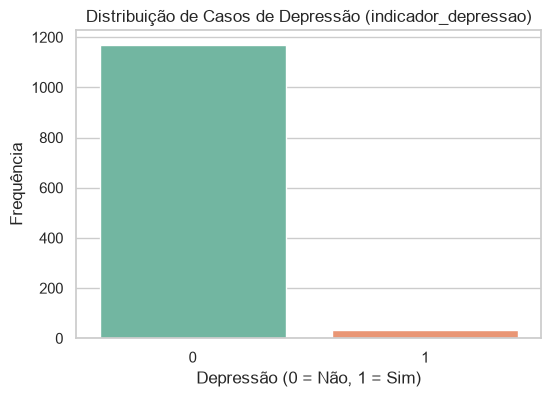

indicador_depressao
0    1169
1      31
Name: count, dtype: int64
indicador_depressao
0    97.416667
1     2.583333
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='indicador_depressao', palette='Set2')
plt.title('Distribuição da Variável Resposta (Depressão)')
plt.xlabel('Depressão (0 = Não, 1 = Sim)')
plt.ylabel('Frequência')
plt.show()

print(df['indicador_depressao'].value_counts())
print(df['indicador_depressao'].value_counts(normalize=True) * 100)

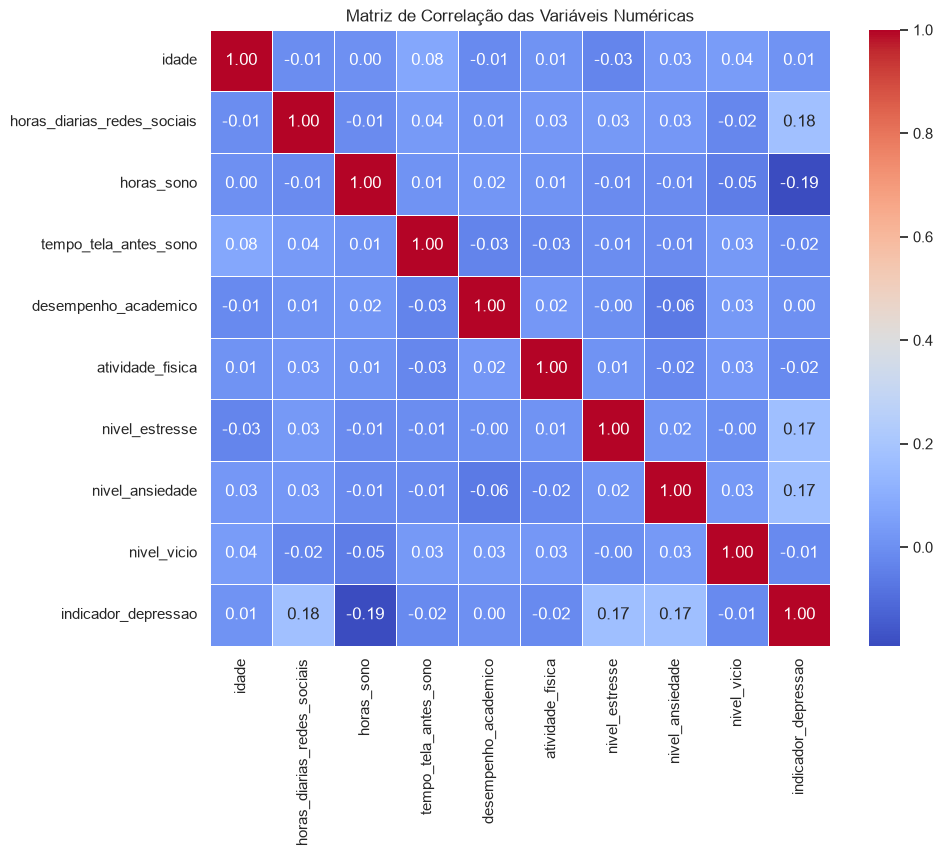

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlação entre as Variáveis Numéricas')
plt.show()

## Tratamento de Variáveis Categóricas

In [7]:
df_processed = df.copy()

# Gênero (0: masc, 1: fem)
df_processed['genero'] = df_processed['genero'].map({'masculino': 0, 'feminino': 1})

# Interação social em escala ordinal
df_processed['nivel_interacao_social'] = df_processed['nivel_interacao_social'].map({'baixo': 0, 'medio': 1, 'alto': 2})

# One-hot encoding na plataforma de redes sociais
df_processed = pd.get_dummies(df_processed, columns=['uso_plataforma'], prefix='plataforma')
plataforma_cols = [col for col in df_processed.columns if col.startswith('plataforma_')]
df_processed[plataforma_cols] = df_processed[plataforma_cols].astype(int)

df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   idade                        1200 non-null   int64  
 1   genero                       1200 non-null   int64  
 2   horas_diarias_redes_sociais  1200 non-null   float64
 3   horas_sono                   1200 non-null   float64
 4   tempo_tela_antes_sono        1200 non-null   float64
 5   desempenho_academico         1200 non-null   float64
 6   atividade_fisica             1200 non-null   float64
 7   nivel_interacao_social       1200 non-null   int64  
 8   nivel_estresse               1200 non-null   int64  
 9   nivel_ansiedade              1200 non-null   int64  
 10  nivel_vicio                  1200 non-null   int64  
 11  indicador_depressao          1200 non-null   int64  
 12  plataforma_Ambas             1200 non-null   int64  
 13  plataforma_Instagr

## Normalização de Dados

In [8]:
cols_to_scale = [
    'idade', 'horas_diarias_redes_sociais', 'horas_sono', 
    'tempo_tela_antes_sono', 'desempenho_academico', 
    'atividade_fisica', 'nivel_estresse', 'nivel_ansiedade', 'nivel_vicio'
]

scaler = StandardScaler()
df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])

# Espiando como ficou:
df_processed.head()

,idade,genero,horas_diarias_redes_sociais,horas_sono,tempo_tela_antes_sono,desempenho_academico,atividade_fisica,nivel_interacao_social,nivel_estresse,nivel_ansiedade,nivel_vicio,indicador_depressao,plataforma_Ambas,plataforma_Instagram,plataforma_TikTok
0,-0.954099,0,1.657833,0.659177,1.618830,0.034026,0.834276,0,-1.187367,-1.272335,-1.613389,0,0,1,0
1,1.519796,1,-1.299649,1.075244,1.618830,0.398282,-0.368593,2,0.880116,-1.622199,1.567444,0,0,0,1
2,0.530238,1,-1.595397,0.797866,-1.731436,1.612470,-1.743301,2,-1.187367,-0.572609,-1.259963,0,0,1,0
3,-0.459320,0,1.411376,0.312455,-0.195897,0.849266,-0.368593,1,-1.531947,0.476980,1.214018,0,0,0,1
4,-0.459320,1,0.080509,-1.074435,1.758424,-1.076088,0.662437,1,-0.842786,-0.222746,-1.259963,0,1,0,0


## Exportação da Base Tratada

In [9]:
output_path = 'Teen_Mental_Health_Dataset_Processed.csv'
df_processed.to_csv(output_path, index=False)
print(f"Base normalizada salva com sucesso em: {output_path}")

Sucesso! Dataset normalizado e pronto para Machine Learning salvo em: ../1_DataSet/Teen_Mental_Health_Dataset_Processed.csv
